In [1]:
from pathlib import Path 

import cv2
import IPython
import pandas as pd
from insightface.app import FaceAnalysis

In [2]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [67]:
def draw_face(row):
    img = cv2.imread(str(Path('../../test_images').joinpath(row[0]['name'])))
    for r in row:
        x1 = int(r['x1'])
        y1 = int(r['y1'])
        x2 = int(r['x2'])
        y2 = int(r['y2'])
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 1)
    show_image(img)

In [51]:
def calc_overlap(a, b):
    x_overlap = max(0, min(a['x2'], b['x2']) - max(a['x1'], a['x1']))
    y_overlap = max(0, min(a['y2'], b['y2']) - max(a['y1'], b['y1']))
    intersection_area = x_overlap * y_overlap
    area_a = (a['x2'] - a['x1']) * (a['y2'] - a['y1'])
    area_b = (b['x2'] - b['x1']) * (b['y2'] - b['y1'])
    min_area = min(area_a, area_b)
    overlap_pct = intersection_area / area_a
    return overlap_pct

In [160]:
def compare(name, a, b):
    img = cv2.imread(str(Path('../../test_images').joinpath(name)))
    a_ = a[a['name'] == name]
    b_ = b[b['name'] == name]

    for idx, row in a_.iterrows():
        if pd.isnull(row['x1']):
            continue
        x1 = int(row['x1'])
        y1 = int(row['y1'])
        x2 = int(row['x2'])
        y2 = int(row['y2'])
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 1)
    
    for idx, row in b_.iterrows():
        if pd.isnull(row['x1']):
            continue
        x1 = int(row['x1'])
        y1 = int(row['y1'])
        x2 = int(row['x2'])
        y2 = int(row['y2'])
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 1)
    
    show_image(img)

In [61]:
def show_by_name(name):
    fp = Path('../../test_images').joinpath(name)
    img = cv2.imread(str(fp))
    show_image(img)

In [6]:
faces = pd.read_csv('../../data/faces.csv', index_col=0)
faces.head()

,name,img_height,img_width,x1,y1,x2,y2,width,height,area,pct_of_frame,face_num
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,1080.0,1920.0,323.0,5.0,919.0,731.0,596.0,726.0,432696.0,0.208669,0.0
1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,1080.0,1920.0,262.0,42.0,614.0,507.0,352.0,465.0,163680.0,0.078935,0.0
2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080.0,1920.0,484.0,389.0,671.0,617.0,187.0,228.0,42636.0,0.020561,0.0
3,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080.0,1920.0,1003.0,42.0,1195.0,261.0,192.0,219.0,42048.0,0.020278,1.0
4,Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,1080.0,1920.0,1121.0,66.0,1662.0,824.0,541.0,758.0,410078.0,0.197761,0.0


In [46]:
row = faces[faces['face_num'] > 1].iloc[0]
row

name            Billions.S04E10.1080p.WEBRip.x265-RARBG_15288.png
img_height                                                 1080.0
img_width                                                  1920.0
x1                                                         1500.0
y1                                                          383.0
x2                                                         1801.0
y2                                                          709.0
width                                                       301.0
height                                                      326.0
area                                                      98126.0
pct_of_frame                                             0.047322
face_num                                                      2.0
Name: 21, dtype: object

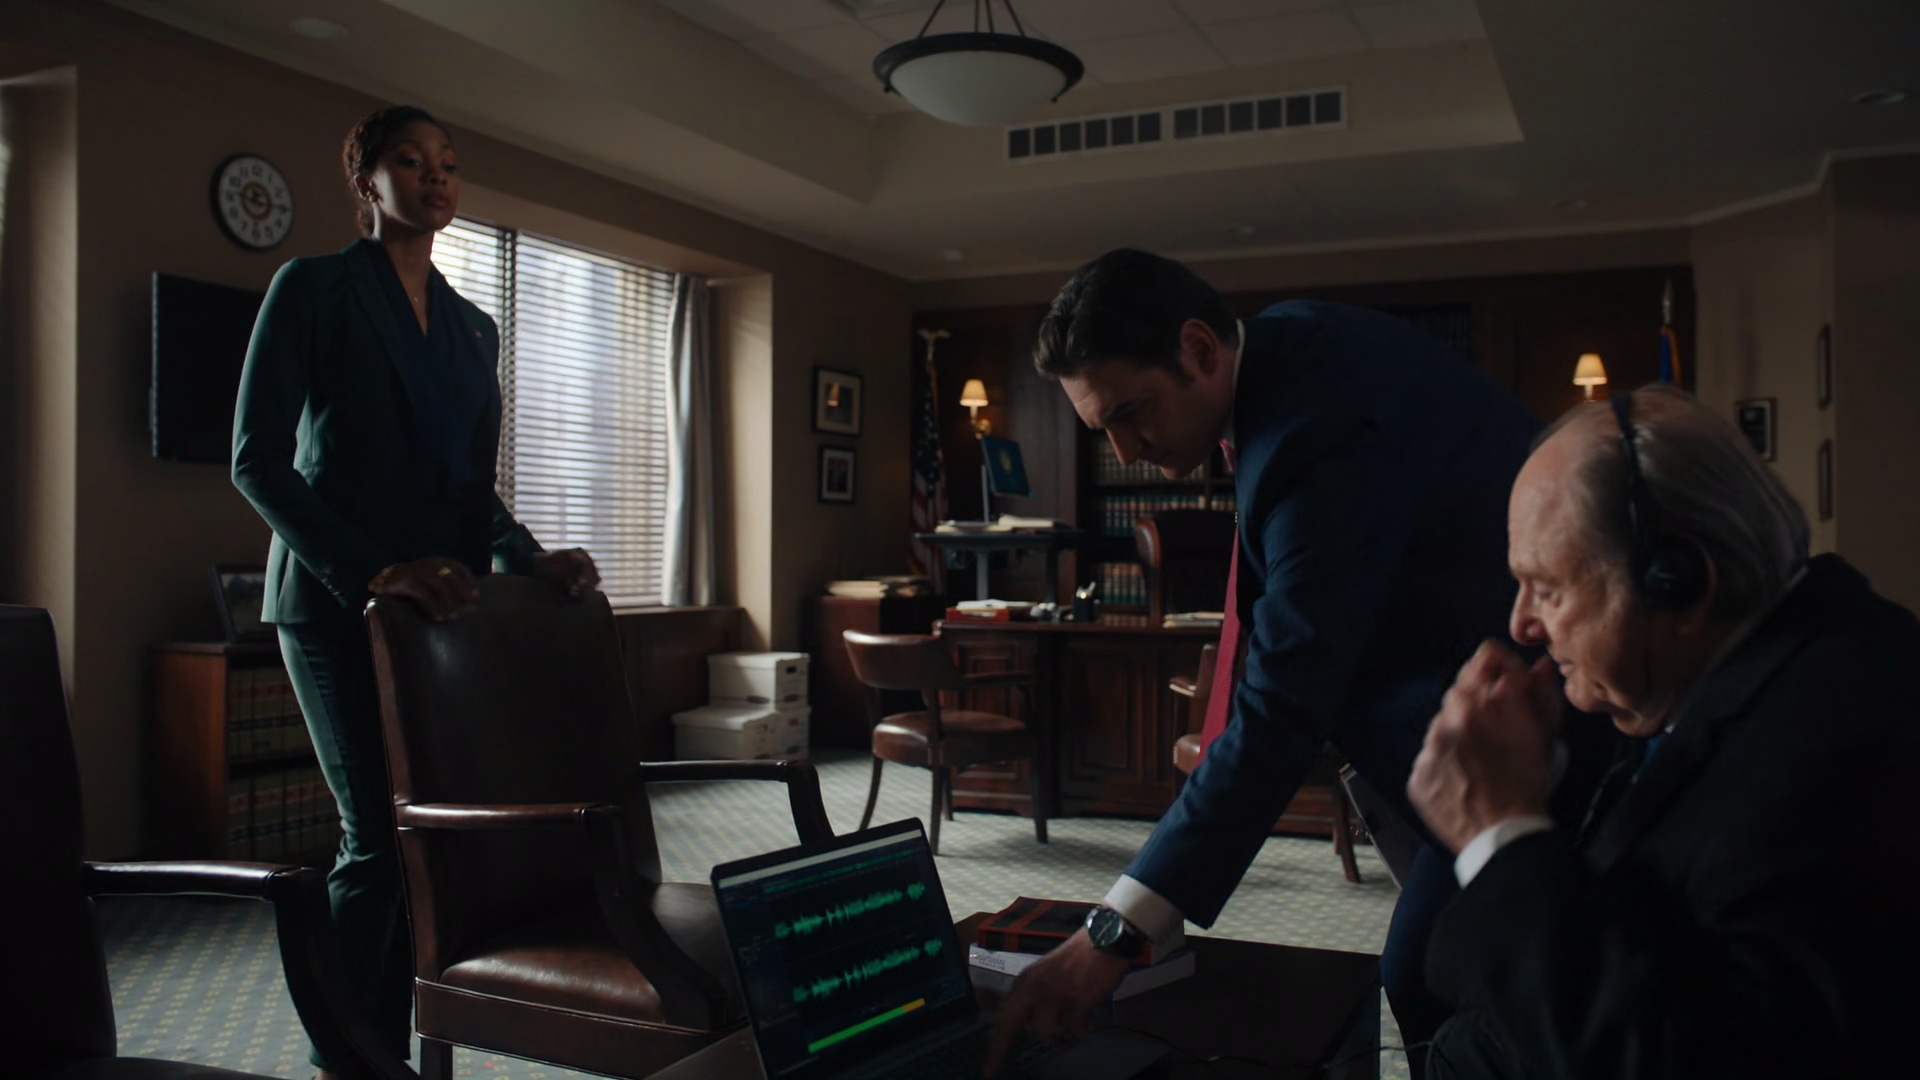

In [47]:
fp = Path('../../test_images/').joinpath(row['name'])
img = cv2.imread(str(fp))
show_image(img)

In [12]:
app = FaceAnalysis(allowed_modules=['detection'], name='buffalo_l')
app.prepare(ctx_id=0, det_size=(640, 640))

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/amos/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/amos/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/amos/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/amos/.insightface/models/buffalo_l/genderage.onnx genderage


2025-02-11 14:05:52.397831933 [E:onnxruntime:Default, provider_bridge_ort.cc:1862 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1539 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_cuda.so with error: libcudnn.so.9: cannot open shared object file: No such file or directory

2025-02-11 14:05:52.778973332 [E:onnxruntime:Default, provider_bridge_ort.cc:1862 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1539 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_cuda.so with error: libcudnn.so.9: cannot open shared object file: No such file or directory

2025-02-11 14:05:52.799822964 [E:onnxruntime:Default, provider_bridge_ort.cc:1862 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1539 onn

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/amos/.insightface/models/buffalo_l/w600k_r50.onnx recognition
set det-size: (640, 640)


In [13]:
df = pd.read_csv('../../test_results/scrfd.csv', index_col=0)
df.head()

,x1,y1,x2,y2,width,height,area,confidence,face_num,img_width,img_height,pct_of_frame,name,duration
0,999.0,140.0,1538.0,919.0,539.0,779.0,419881.0,0.866526,0.0,1920.0,1080.0,0.202489,The.X-Files.S02E18.Fearful.Symmetry.1080p.BluR...,0.120
1,206.0,151.0,606.0,865.0,400.0,714.0,285600.0,0.691233,1.0,1920.0,1080.0,0.137731,The.X-Files.S02E18.Fearful.Symmetry.1080p.BluR...,0.120
2,148.0,118.0,431.0,570.0,283.0,452.0,127916.0,0.894302,0.0,1920.0,1080.0,0.061688,Seinfeld.S06E08.1080p.WEBRip.x265-RARBG_15528.png,0.118
3,1433.0,211.0,1720.0,633.0,287.0,422.0,121114.0,0.852575,1.0,1920.0,1080.0,0.058408,Seinfeld.S06E08.1080p.WEBRip.x265-RARBG_15528.png,0.118
4,1158.0,272.0,1497.0,814.0,339.0,542.0,183738.0,0.733005,0.0,1920.0,1080.0,0.088608,The.X-Files.S01E01.Pilot.1080p.BluRay.10Bit.Dt...,0.113


In [17]:
filenames = faces['name'].unique().tolist()
print(len(filenames))

1064


In [27]:
temp = faces[faces['name'] == row['name']]
temp

,name,img_height,img_width,x1,y1,x2,y2,width,height,area,pct_of_frame,face_num
19,Billions.S04E10.1080p.WEBRip.x265-RARBG_15288.png,1080.0,1920.0,345.0,105.0,463.0,231.0,118.0,126.0,14868.0,0.007170,0.0
20,Billions.S04E10.1080p.WEBRip.x265-RARBG_15288.png,1080.0,1920.0,1037.0,245.0,1238.0,483.0,201.0,238.0,47838.0,0.023070,1.0
21,Billions.S04E10.1080p.WEBRip.x265-RARBG_15288.png,1080.0,1920.0,1500.0,383.0,1801.0,709.0,301.0,326.0,98126.0,0.047322,2.0


In [22]:
eph = df[df['name'] == row['name']]
eph

,x1,y1,x2,y2,width,height,area,confidence,face_num,img_width,img_height,pct_of_frame,name,duration
2009,375.0,121.0,458.0,228.0,83.0,107.0,8881.0,0.878210,0.0,1920.0,1080.0,0.004283,Billions.S04E10.1080p.WEBRip.x265-RARBG_15288.png,0.085
2010,1505.0,494.0,1646.0,714.0,141.0,220.0,31020.0,0.804193,1.0,1920.0,1080.0,0.014959,Billions.S04E10.1080p.WEBRip.x265-RARBG_15288.png,0.085
2011,1062.0,353.0,1225.0,478.0,163.0,125.0,20375.0,0.706265,2.0,1920.0,1080.0,0.009826,Billions.S04E10.1080p.WEBRip.x265-RARBG_15288.png,0.085


In [31]:
t = temp.iloc[0]
e = eph.iloc[0]
print(t['x1'], t['y1'], t['x2'], t['y2'])
print(e['x1'], e['y1'], e['x2'], e['y2'])

345.0 105.0 463.0 231.0
375.0 121.0 458.0 228.0


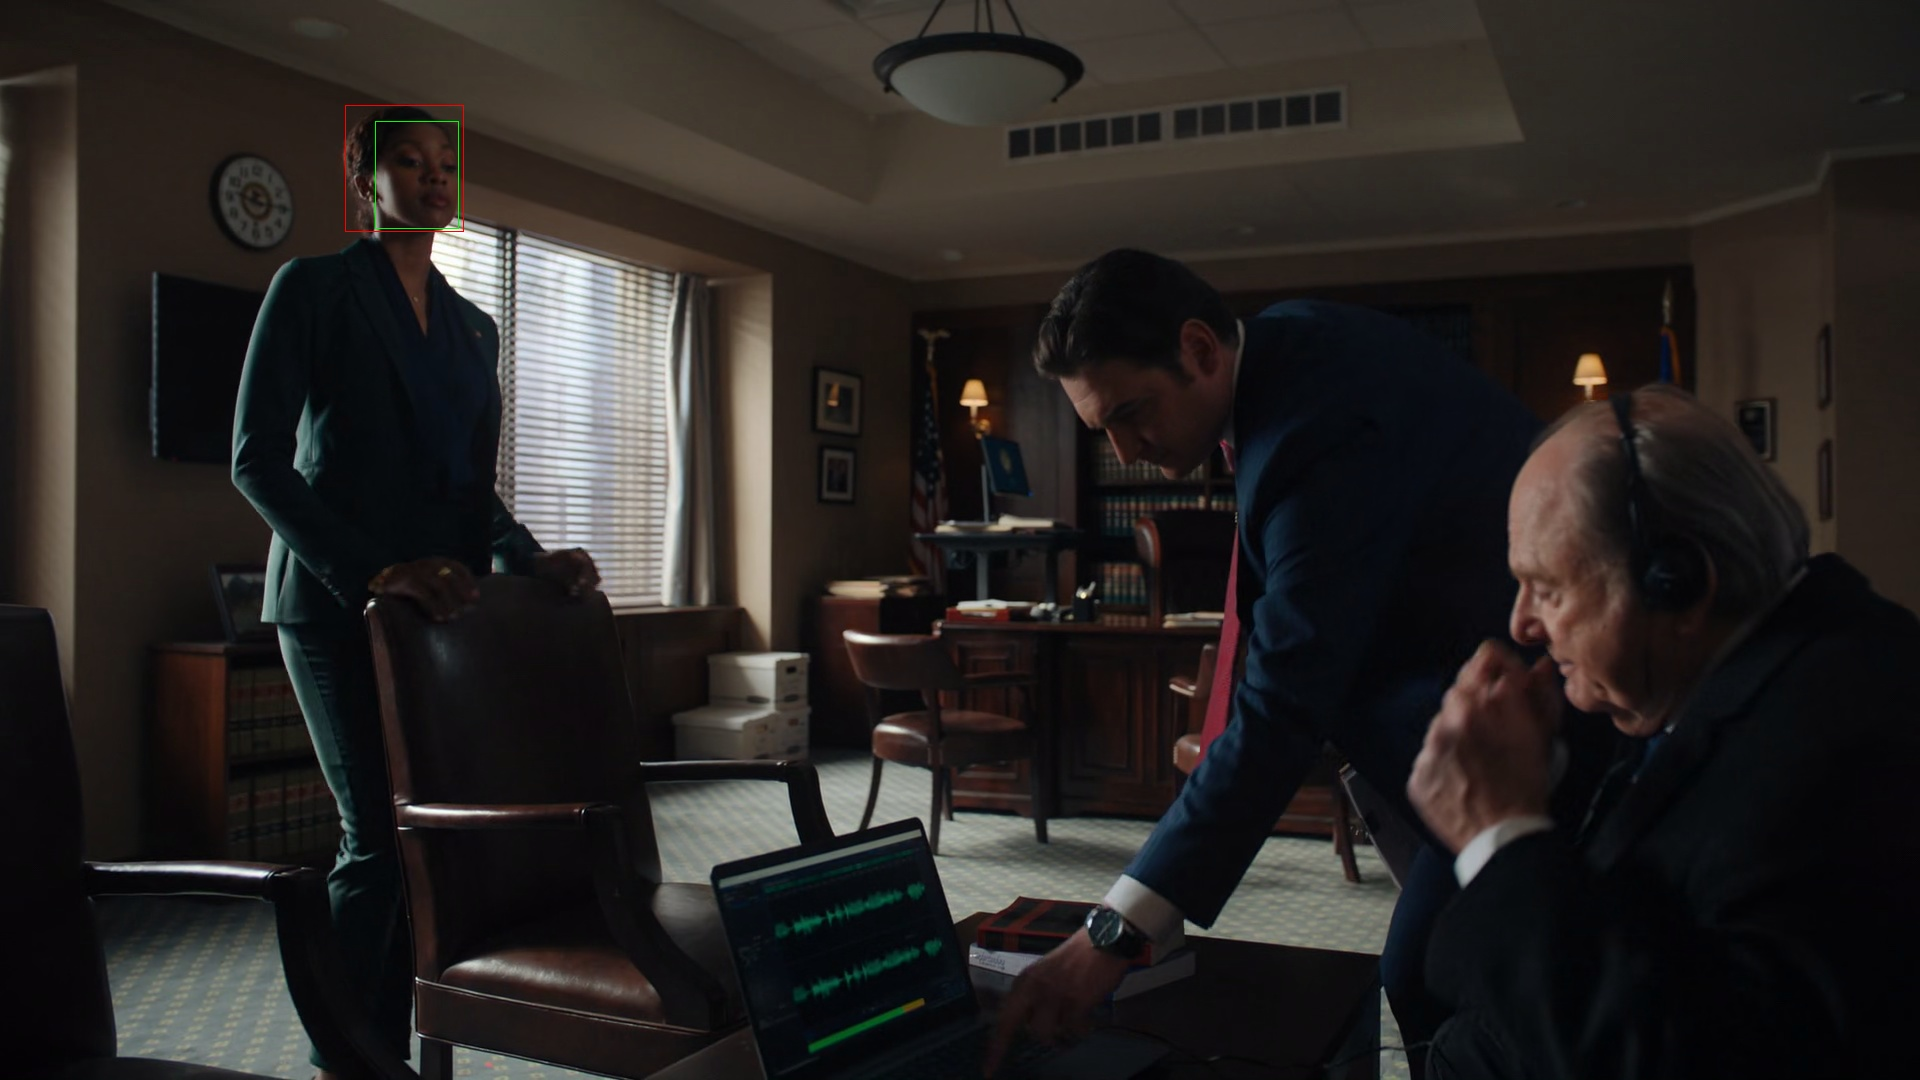

1.0


In [60]:
img_copy = img.copy()
cv2.rectangle(img_copy, (int(t['x1']), int(t['y1'])), (int(t['x2']), int(t['y2'])), (0, 0, 255), 1)
cv2.rectangle(img_copy, (int(e['x1']), int(e['y1'])), (int(e['x2']), int(e['y2'])), (0, 255, 0), 1)
show_image(img_copy)
print(calc_overlap(e, t))

In [24]:
test = faces.merge(df,
                   how='left',
                   on=['name', 'face_num'])
print(faces.shape[0], test.shape[0])

1997 1997


In [25]:
test = df.merge(test,
                how='left',
                on=['name', 'face_num'])
print(test.shape[0])

2137


In [26]:
test.head()

,x1,y1,x2,y2,width,height,area,confidence_x,face_num,img_width,...,x2_y,y2_y,width_y,height_y,area_y,confidence_y,img_width_y,img_height_y,pct_of_frame_y,duration_y
0,999.0,140.0,1538.0,919.0,539.0,779.0,419881.0,0.866526,0.0,1920.0,...,1538.0,919.0,539.0,779.0,419881.0,0.866526,1920.0,1080.0,0.202489,0.120
1,206.0,151.0,606.0,865.0,400.0,714.0,285600.0,0.691233,1.0,1920.0,...,606.0,865.0,400.0,714.0,285600.0,0.691233,1920.0,1080.0,0.137731,0.120
2,148.0,118.0,431.0,570.0,283.0,452.0,127916.0,0.894302,0.0,1920.0,...,431.0,570.0,283.0,452.0,127916.0,0.894302,1920.0,1080.0,0.061688,0.118
3,1433.0,211.0,1720.0,633.0,287.0,422.0,121114.0,0.852575,1.0,1920.0,...,1720.0,633.0,287.0,422.0,121114.0,0.852575,1920.0,1080.0,0.058408,0.118
4,1158.0,272.0,1497.0,814.0,339.0,542.0,183738.0,0.733005,0.0,1920.0,...,1497.0,814.0,339.0,542.0,183738.0,0.733005,1920.0,1080.0,0.088608,0.113


In [166]:
data = []
names = test['name'].unique().tolist()
for name in names:
    a = df[df['name'] == name].copy()        # Predicted
    b = faces[faces['name'] == name].copy()  # Ground truth 

    for a_idx, a_row in a.iterrows():
        # Check for true negatives. If both rows lack coordinates, then it is a true negative.
        if pd.isnull(a_row['x1']) and pd.isnull(b_row['x1']):
            status = 'tn' 
        else:
            status = 'fp'
            # Check each prediction against the ground truth faces. If the prediction area overlaps by more than 50%, then it is a true positive.
            for b_idx, b_row in b.iterrows():
                overlap_pct = calc_overlap(a_row, b_row)
                if overlap_pct > 0.5:
                    status = 'tp'
                    b = b.drop(b_idx, axis=0) # Drop true positive from ground truth set.
                    break 
        a.loc[a_idx, 'status'] = status

    # Since the true positives have been removed from the ground truth set, all that should remain are the false negatives.
    b = b[b['x1'].notna()]
    b = b.assign(status='fn')
    [data.append(a.iloc[n]) for n in range(a.shape[0])]
    [data.append(b.iloc[n]) for n in range(b.shape[0])]
result_df = pd.DataFrame(data)
result_df.head()

,x1,y1,x2,y2,width,height,area,confidence,face_num,img_width,img_height,pct_of_frame,name,duration,overlap,status
0,999.0,140.0,1538.0,919.0,539.0,779.0,419881.0,0.866526,0.0,1920.0,1080.0,0.202489,The.X-Files.S02E18.Fearful.Symmetry.1080p.BluR...,0.120,0.884744,tp
1,206.0,151.0,606.0,865.0,400.0,714.0,285600.0,0.691233,1.0,1920.0,1080.0,0.137731,The.X-Files.S02E18.Fearful.Symmetry.1080p.BluR...,0.120,0.000000,tp
2,148.0,118.0,431.0,570.0,283.0,452.0,127916.0,0.894302,0.0,1920.0,1080.0,0.061688,Seinfeld.S06E08.1080p.WEBRip.x265-RARBG_15528.png,0.118,0.000000,tp
3,1433.0,211.0,1720.0,633.0,287.0,422.0,121114.0,0.852575,1.0,1920.0,1080.0,0.058408,Seinfeld.S06E08.1080p.WEBRip.x265-RARBG_15528.png,0.118,0.655177,tp
4,1158.0,272.0,1497.0,814.0,339.0,542.0,183738.0,0.733005,0.0,1920.0,1080.0,0.088608,The.X-Files.S01E01.Pilot.1080p.BluRay.10Bit.Dt...,0.113,0.871527,tp


In [167]:
g = result_df.groupby('status').count()
g[['name']]

,name
status,
fn,94
fp,318
tn,9
tp,1810


In [168]:
accuracy = (g.at['tn', 'name'] + g.at['tp', 'name'])/g['name'].sum()
accuracy

0.815329448677723

In [169]:
fn = result_df[result_df['status'] == 'fn']
fn

,x1,y1,x2,y2,width,height,area,confidence,face_num,img_width,img_height,pct_of_frame,name,duration,overlap,status
1064,1021.0,259.0,1097.0,348.0,76.0,89.0,6764.0,NaN,3.0,1440.0,1080.0,0.004349,Scrubs S04E03 My New Game [1080p x265 10bit J...,NaN,NaN,fn
1560,22.0,459.0,70.0,528.0,48.0,69.0,3312.0,NaN,1.0,1920.0,1080.0,0.001597,The.X-Files.S08E02.Without.1080p.BluRay.10Bit....,NaN,NaN,fn
1667,62.0,76.0,156.0,182.0,94.0,106.0,9964.0,NaN,1.0,640.0,480.0,0.032435,Will.&.Grace.S01E20.Saving.Grace.480p.Web.h264...,NaN,NaN,fn
760,530.0,457.0,784.0,723.0,254.0,266.0,67564.0,NaN,1.0,1920.0,1080.0,0.032583,Modern.Family.S01E15.1080p.BluRay.x265-RARBG_0...,NaN,NaN,fn
693,235.0,0.0,372.0,345.0,137.0,345.0,47265.0,NaN,3.0,1920.0,1080.0,0.022794,Lost.Girl.S02E15.Table.For.Fae.BluRay.10Bit.10...,NaN,NaN,fn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1762,274.0,60.0,332.0,139.0,58.0,79.0,4582.0,NaN,1.0,640.0,480.0,0.014915,Will.&.Grace.S05E18.Fagmalion.Part.Four.The.Gu...,NaN,NaN,fn
970,1340.0,123.0,1498.0,505.0,158.0,382.0,60356.0,NaN,1.0,1920.0,1080.0,0.029107,Modern.Family.S10E11.A.Moving.Day.1080p.DSNP.W...,NaN,NaN,fn
82,197.0,199.0,264.0,297.0,67.0,98.0,6566.0,NaN,3.0,1440.0,1080.0,0.004222,Cheers.S02E20.1080p.BluRay.x265-RARBG_15768.png,NaN,NaN,fn
333,415.0,206.0,488.0,300.0,73.0,94.0,6862.0,NaN,7.0,1440.0,1080.0,0.004412,Cheers.S11E19.1080p.BluRay.x265-RARBG_00840.png,NaN,NaN,fn


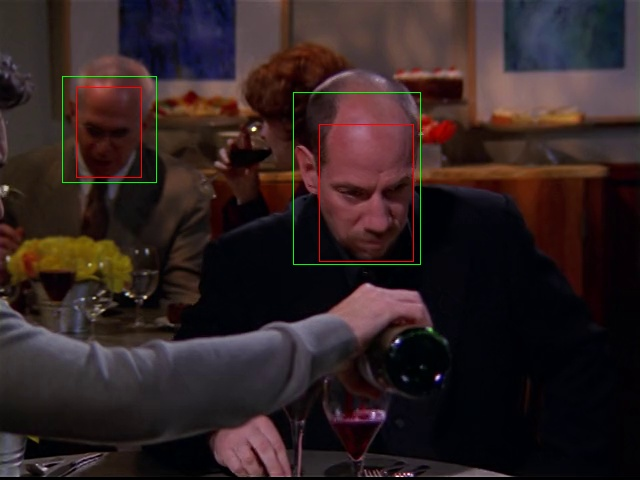

In [170]:
compare(fn.iloc[2]['name'], df, faces)

In [172]:
name = fn.iloc[2]['name']
name

'Will.&.Grace.S01E20.Saving.Grace.480p.Web.h264-JBee_25848.png'

In [192]:
b = faces[faces['name'] == name]
b

,name,img_height,img_width,x1,y1,x2,y2,width,height,area,pct_of_frame,face_num
1666,Will.&.Grace.S01E20.Saving.Grace.480p.Web.h264...,480.0,640.0,293.0,92.0,420.0,264.0,127.0,172.0,21844.0,0.071107,0.0
1667,Will.&.Grace.S01E20.Saving.Grace.480p.Web.h264...,480.0,640.0,62.0,76.0,156.0,182.0,94.0,106.0,9964.0,0.032435,1.0


In [193]:
a = df[df['name'] == name]
a

,x1,y1,x2,y2,width,height,area,confidence,face_num,img_width,img_height,pct_of_frame,name,duration,overlap
65,76.0,87.0,141.0,177.0,65.0,90.0,5850.0,0.844364,0.0,640.0,480.0,0.019043,Will.&.Grace.S01E20.Saving.Grace.480p.Web.h264...,0.09,0.713569
66,319.0,124.0,413.0,261.0,94.0,137.0,12878.0,0.805335,1.0,640.0,480.0,0.041921,Will.&.Grace.S01E20.Saving.Grace.480p.Web.h264...,0.09,0.547170


In [198]:
a = df[df['name'] == name]
b = faces[faces['name'] == name]

for a_idx, a_row in a.iterrows():
    # Check for true negatives. If both rows lack coordinates, then it is a true negative.
    if pd.isnull(a_row['x1']) and pd.isnull(b_row['x1']):
        status = 'tn' 
    else:
        status = 'fp'
        # Check each prediction against the ground truth faces. If the prediction area overlaps by more than 50%, then it is a true positive.
        for b_idx, b_row in b.iterrows():
            overlap_pct = calc_overlap(a_row, b_row)
            if overlap_pct > 0.5:
                status = 'tp'
                # b = b.drop(b_idx, axis=0) # Drop true positive from ground truth set.
                break 
    print(status)

tp
tp


In [199]:
b

,name,img_height,img_width,x1,y1,x2,y2,width,height,area,pct_of_frame,face_num
1666,Will.&.Grace.S01E20.Saving.Grace.480p.Web.h264...,480.0,640.0,293.0,92.0,420.0,264.0,127.0,172.0,21844.0,0.071107,0.0
1667,Will.&.Grace.S01E20.Saving.Grace.480p.Web.h264...,480.0,640.0,62.0,76.0,156.0,182.0,94.0,106.0,9964.0,0.032435,1.0


In [197]:
a

,x1,y1,x2,y2,width,height,area,confidence,face_num,img_width,img_height,pct_of_frame,name,duration,overlap
65,76.0,87.0,141.0,177.0,65.0,90.0,5850.0,0.844364,0.0,640.0,480.0,0.019043,Will.&.Grace.S01E20.Saving.Grace.480p.Web.h264...,0.09,0.713569
66,319.0,124.0,413.0,261.0,94.0,137.0,12878.0,0.805335,1.0,640.0,480.0,0.041921,Will.&.Grace.S01E20.Saving.Grace.480p.Web.h264...,0.09,0.547170
